In [13]:
import glob
import random
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
# Read in Dartmouth isochrone files
from isochrones.dartmouth_iso import load_isochrones, read_dartmouth_iso
isos = load_isochrones("isochrones")
iso5 = isos["5gyr"]
iso13 = isos["13gyr"]

In [15]:
# Read in SDSS data
from sdss_data.sdss_loader import load_sdss_csv
df = load_sdss_csv("sdss_data/fields/sdss_target.csv")

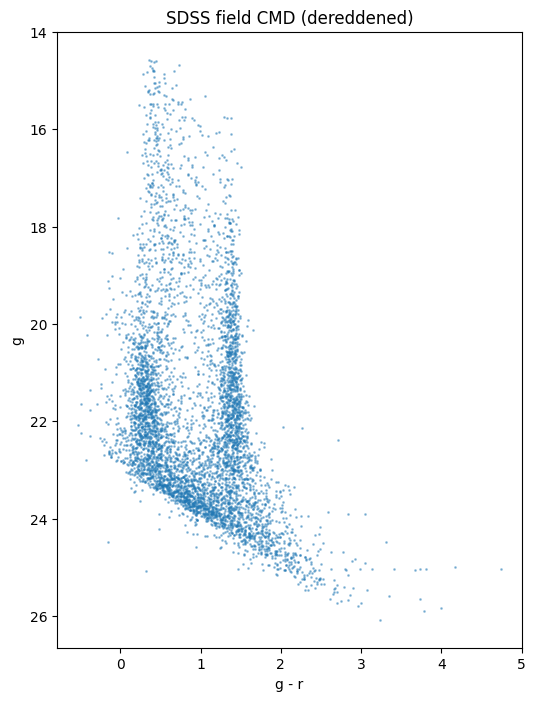

In [16]:
# Plot SDSS data on CMD without reddening as a sanity check
import matplotlib.pyplot as plt
plt.figure(figsize=(6,8))
plt.scatter(df["g_r"], df["g0"], s=1, alpha=0.4)
plt.gca().invert_yaxis()
plt.xlabel("g - r")
plt.ylabel("g")
plt.title("SDSS field CMD (dereddened)")
plt.show()

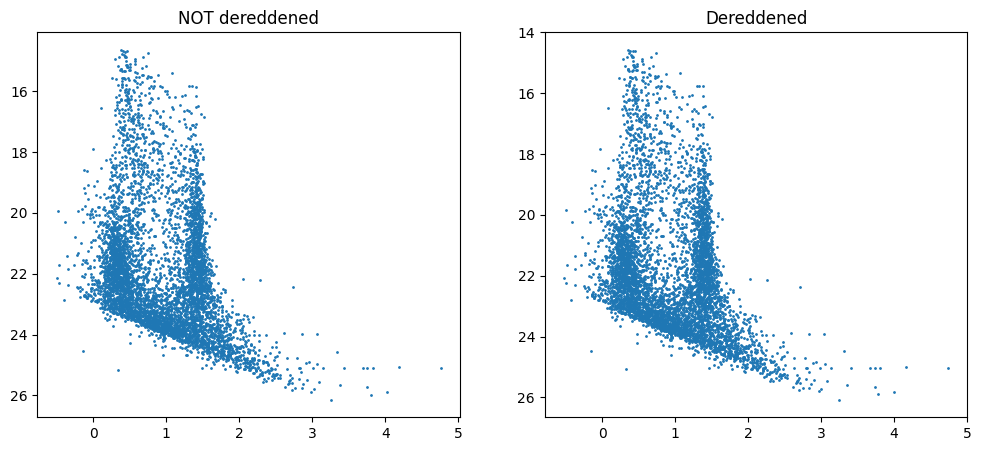

In [17]:
# Plot dereddened vs reddened CMD side by side
plt.figure(figsize=(12,5))

# reddened
plt.subplot(1,2,1)
plt.scatter(df["psfMag_g"]-df["psfMag_r"], df["psfMag_g"], s=1)
plt.gca().invert_yaxis()
plt.title("NOT dereddened")

# dereddened
plt.subplot(1,2,2)
plt.scatter(df["g_r"], df["g0"], s=1)
plt.gca().invert_yaxis()
plt.title("Dereddened")

plt.show()

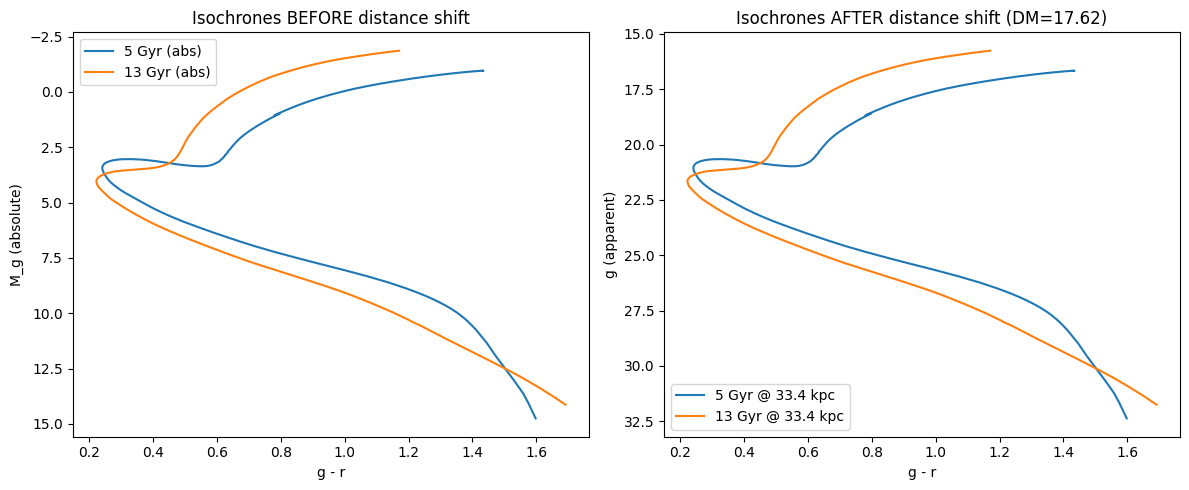

Distance modulus used: DM = 17.6187 mag for d = 33.4 kpc


In [19]:

# --- Distance modulus for d = 33.4 kpc ---
d_pc = 33_400.0
DM = 5.0 * np.log10(d_pc / 10.0)   # ~17.62

def iso_before_after(iso, DM):
    """Return (color_abs, Mg_abs, color_app, g_app) for one isochrone."""
    df_iso = iso.df.copy()

    # BEFORE: absolute magnitudes (intrinsic)
    color_abs = df_iso["sdss_g"] - df_iso["sdss_r"]
    Mg_abs = df_iso["sdss_g"]

    # AFTER: shifted to apparent magnitudes at the Sgr distance
    g_app = df_iso["sdss_g"] + DM
    r_app = df_iso["sdss_r"] + DM
    color_app = g_app - r_app

    return color_abs, Mg_abs, color_app, g_app


c5_abs, g5_abs, c5_app, g5_app = iso_before_after(iso5, DM)
c13_abs, g13_abs, c13_app, g13_app = iso_before_after(iso13, DM)

# --- Plot BEFORE/AFTER for distance correction ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# BEFORE (absolute mags)
ax[0].plot(c5_abs, g5_abs, lw=1.5, label="5 Gyr (abs)")
ax[0].plot(c13_abs, g13_abs, lw=1.5, label="13 Gyr (abs)")
ax[0].invert_yaxis()
ax[0].set_xlabel("g - r")
ax[0].set_ylabel("M_g (absolute)")
ax[0].set_title("Isochrones BEFORE distance shift")
ax[0].legend()

# AFTER (apparent mags at 33.4 kpc)
ax[1].plot(c5_app, g5_app, lw=1.5, label="5 Gyr @ 33.4 kpc")
ax[1].plot(c13_app, g13_app, lw=1.5, label="13 Gyr @ 33.4 kpc")
ax[1].invert_yaxis()
ax[1].set_xlabel("g - r")
ax[1].set_ylabel("g (apparent)")
ax[1].set_title(f"Isochrones AFTER distance shift (DM={DM:.2f})")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Distance modulus used: DM = {DM:.4f} mag for d = {d_pc/1000:.1f} kpc")

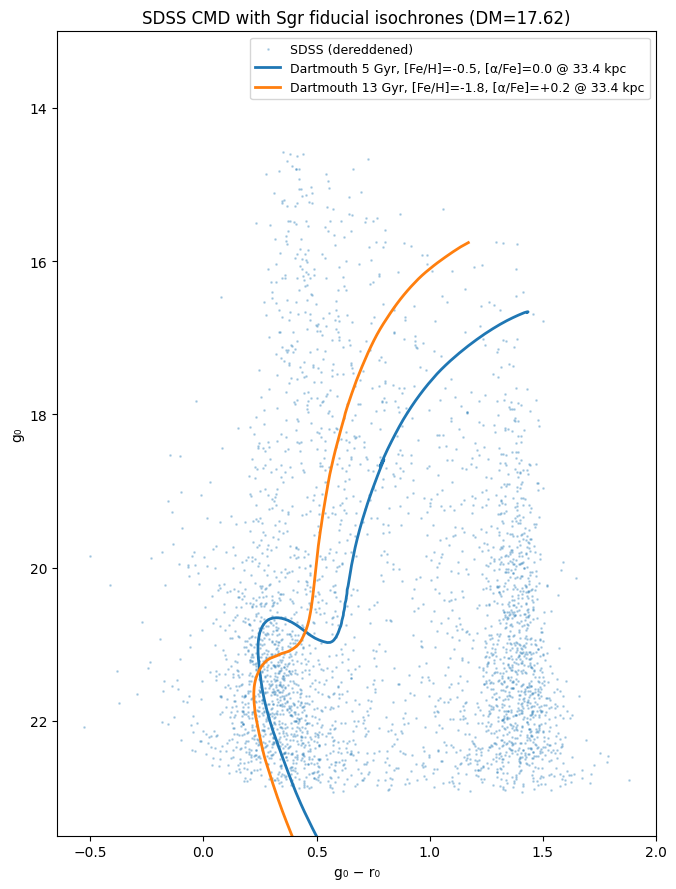

Overlay used DM = 17.6187 mag; SDSS plotted points = 3206 / 5448 (after quality cut)


In [20]:
# --- Overlay dereddened SDSS CMD with distance-shifted Dartmouth isochrones ---
# Distance modulus for Sgr field (33.4 kpc)
d_pc = 33_400.0
DM = 5.0 * np.log10(d_pc / 10.0)

# light quality cut to keep the CMD readable
mask = (
    (df["psfMagErr_g"] < 0.15) &
    (df["psfMagErr_r"] < 0.15) &
    (df["g0"] < 23.5) &
    (df["r0"] < 23.5)
)
d = df[mask].copy()

def shifted_iso(iso, DM):
    """Return (color, mag) arrays for plotting an isochrone shifted to apparent mags."""
    iso_df = iso.df
    g_app = iso_df["sdss_g"] + DM
    r_app = iso_df["sdss_r"] + DM
    color = g_app - r_app
    return color.to_numpy(), g_app.to_numpy()

c5, g5 = shifted_iso(iso5, DM)
c13, g13 = shifted_iso(iso13, DM)

plt.figure(figsize=(7, 9))

# SDSS (dereddened)
plt.scatter(d["g_r"], d["g0"], s=1, alpha=0.25, label="SDSS (dereddened)")

# Isochrones (shifted to 33.4 kpc; no extinction added)
plt.plot(c5, g5, lw=2, label="Dartmouth 5 Gyr, [Fe/H]=-0.5, [α/Fe]=0.0 @ 33.4 kpc")
plt.plot(c13, g13, lw=2, label="Dartmouth 13 Gyr, [Fe/H]=-1.8, [α/Fe]=+0.2 @ 33.4 kpc")

plt.gca().invert_yaxis()
plt.xlabel("g₀ − r₀")
plt.ylabel("g₀")
plt.title(f"SDSS CMD with Sgr fiducial isochrones (DM={DM:.2f})")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()

plt.ylim(23.5, 13)

plt.show()

print(f"Overlay used DM = {DM:.4f} mag; SDSS plotted points = {len(d)} / {len(df)} (after quality cut)")

In [21]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
FIELDS_DIR = "sdss_data/fields"
PATTERN = os.path.join(FIELDS_DIR, "sdss_*.csv")

ERR_MAX = 0.15
G0_MAX = 23.5
R0_MAX = 23.5

# Sgr distance
d_pc = 33_400.0
DM_SGR = 5.0 * np.log10(d_pc / 10.0)  # ~17.62

# Candidate thresholds
CHI2_THRESH = 6.18        # ~95% for 2 dof
DG_WINDOW   = 0.50        # only compare points within ±0.5 mag in g
NBINS       = 200

# DM consistency window (tune)
DM_TOL = 0.35             # mag; start 0.3–0.5

# -----------------------------
# Isochrone arrays (ABSOLUTE mags!)
# -----------------------------
def iso_abs_arrays(iso):
    """Return absolute-magnitude arrays from Dartmouth isochrone."""
    df = iso.df
    Mg = df["sdss_g"].to_numpy()
    Mr = df["sdss_r"].to_numpy()
    color = Mg - Mr
    return Mg, Mr, color

Mg5, Mr5, col5   = iso_abs_arrays(iso5)
Mg13, Mr13, col13 = iso_abs_arrays(iso13)

def load_field_csv(path):
    df0 = pd.read_csv(path, comment="#")

    # dereddened apparent mags
    df0["g0"] = df0["psfMag_g"] - df0["extinction_g"]
    df0["r0"] = df0["psfMag_r"] - df0["extinction_r"]
    df0["g_r"] = df0["g0"] - df0["r0"]

    df0["sig_g"] = df0["psfMagErr_g"]
    df0["sig_r"] = df0["psfMagErr_r"]

    # quality mask
    m = (
        (df0["sig_g"] < ERR_MAX) &
        (df0["sig_r"] < ERR_MAX) &
        (df0["g0"] < G0_MAX) &
        (df0["r0"] < R0_MAX)
    )
    return df0[m].copy()

def min_chi2_dm_to_iso(star_g0, star_r0, sig_g, sig_r, Mg_iso, Mr_iso, dg_window=0.5, nbins=200):
    """
    For each star, compute:
      - best-fit distance modulus DM_best to the isochrone
      - min chi^2 in (g,r) space at that DM_best

    Model for an isochrone point i:
      g_model = Mg_iso[i] + DM
      r_model = Mr_iso[i] + DM
    For fixed i, chi^2 minimized over DM has an analytic solution.
    """
    # bin iso points by Mg (absolute) is fine because DM shift is constant offset
    gmin, gmax = np.nanmin(Mg_iso), np.nanmax(Mg_iso)
    edges = np.linspace(gmin, gmax, nbins + 1)
    bin_id = np.clip(np.digitize(Mg_iso, edges) - 1, 0, nbins - 1)

    bins = [[] for _ in range(nbins)]
    for i, b in enumerate(bin_id):
        bins[b].append(i)

    # approximate star's absolute Mg ~ g0 - DM_SGR to choose nearby bins
    approx_Mg = star_g0 - DM_SGR
    star_bin = np.clip(np.digitize(approx_Mg, edges) - 1, 0, nbins - 1)

    dg_per_bin = (gmax - gmin) / nbins
    half_bins = max(1, int(np.ceil(dg_window / dg_per_bin)))

    DM_best = np.full_like(star_g0, np.nan, dtype=float)
    chi2_min = np.full_like(star_g0, np.inf, dtype=float)

    w_g = 1.0 / (sig_g**2)
    w_r = 1.0 / (sig_r**2)
    wsum = w_g + w_r

    for j in range(len(star_g0)):
        b0 = max(0, star_bin[j] - half_bins)
        b1 = min(nbins - 1, star_bin[j] + half_bins)

        cand = []
        for b in range(b0, b1 + 1):
            cand.extend(bins[b])
        if not cand:
            continue

        Mg = Mg_iso[cand]
        Mr = Mr_iso[cand]

        # hard gate: compare only iso points whose Mg is within dg_window of approx_Mg
        keep = np.abs(Mg - approx_Mg[j]) <= dg_window
        if not np.any(keep):
            continue
        Mg = Mg[keep]
        Mr = Mr[keep]

        # analytic best DM for each candidate iso point:
        # DM = (w_g*(g0-Mg) + w_r*(r0-Mr)) / (w_g + w_r)
        DM_i = (w_g[j]*(star_g0[j] - Mg) + w_r[j]*(star_r0[j] - Mr)) / wsum[j]

        # residuals at that DM_i
        dg = star_g0[j] - (Mg + DM_i)
        dr = star_r0[j] - (Mr + DM_i)
        chi2 = (dg/sig_g[j])**2 + (dr/sig_r[j])**2

        k = np.argmin(chi2)
        chi2_min[j] = chi2[k]
        DM_best[j] = DM_i[k]

    return chi2_min, DM_best

def define_msto_box_from_iso(Mg_iso, Mr_iso, DM, gbright=19.5, gfaint=22.5, cmin=0.15, cmax=0.65):
    """
    Simple MSTO-ish region in apparent space. Use a conservative box.
    You can tune these bounds if your instructor expects something specific.
    """
    return dict(gmin=20.0, gmax=22.5, cmin=0.15, cmax=0.65)

In [23]:
paths = sorted([p for p in glob.glob(PATTERN) if "FAILED_" not in os.path.basename(p)])
if not paths:
    raise FileNotFoundError(f"No files matched {PATTERN}")

msto = define_msto_box_from_iso(Mg13, Mr13, DM_SGR)

fields = []
for p in paths:
    fid = os.path.basename(p).replace("sdss_", "").replace(".csv", "")
    df = load_field_csv(p)

    # compute best-fit DM + chi2 for each isochrone
    chi2_5,  DM5  = min_chi2_dm_to_iso(df["g0"].to_numpy(), df["r0"].to_numpy(),
                                      np.maximum(df["sig_g"].to_numpy(), 1e-6),
                                      np.maximum(df["sig_r"].to_numpy(), 1e-6),
                                      Mg5, Mr5, dg_window=DG_WINDOW, nbins=NBINS)

    chi2_13, DM13 = min_chi2_dm_to_iso(df["g0"].to_numpy(), df["r0"].to_numpy(),
                                      np.maximum(df["sig_g"].to_numpy(), 1e-6),
                                      np.maximum(df["sig_r"].to_numpy(), 1e-6),
                                      Mg13, Mr13, dg_window=DG_WINDOW, nbins=NBINS)

    df["chi2_5"] = chi2_5
    df["chi2_13"] = chi2_13
    df["DM5_best"] = DM5
    df["DM13_best"] = DM13

    # candidate = good chi2 AND DM near Sgr
    cand5  = np.isfinite(chi2_5)  & (chi2_5 < CHI2_THRESH)  & np.isfinite(DM5)  & (np.abs(DM5 - DM_SGR) < DM_TOL)
    cand13 = np.isfinite(chi2_13) & (chi2_13 < CHI2_THRESH) & np.isfinite(DM13) & (np.abs(DM13 - DM_SGR) < DM_TOL)

    df["cand_5"] = cand5
    df["cand_13"] = cand13
    df["cand_both"] = cand5 & cand13
    df["cand_either"] = cand5 | cand13

    # MSTO mask (for overdensity only)
    in_msto = (
        (df["g0"] >= msto["gmin"]) & (df["g0"] <= msto["gmax"]) &
        (df["g_r"] >= msto["cmin"]) & (df["g_r"] <= msto["cmax"])
    )
    df["in_msto"] = in_msto

    fields.append((fid, df))

# sort target first
fields = sorted(fields, key=lambda t: (t[0] != "target", t[0]))
print(f"Loaded {len(fields)} fields. Using DM_TOL={DM_TOL} mag, CHI2<{CHI2_THRESH}, MSTO box={msto}")

Loaded 31 fields. Using DM_TOL=0.35 mag, CHI2<6.18, MSTO box={'gmin': 20.0, 'gmax': 22.5, 'cmin': 0.15, 'cmax': 0.65}


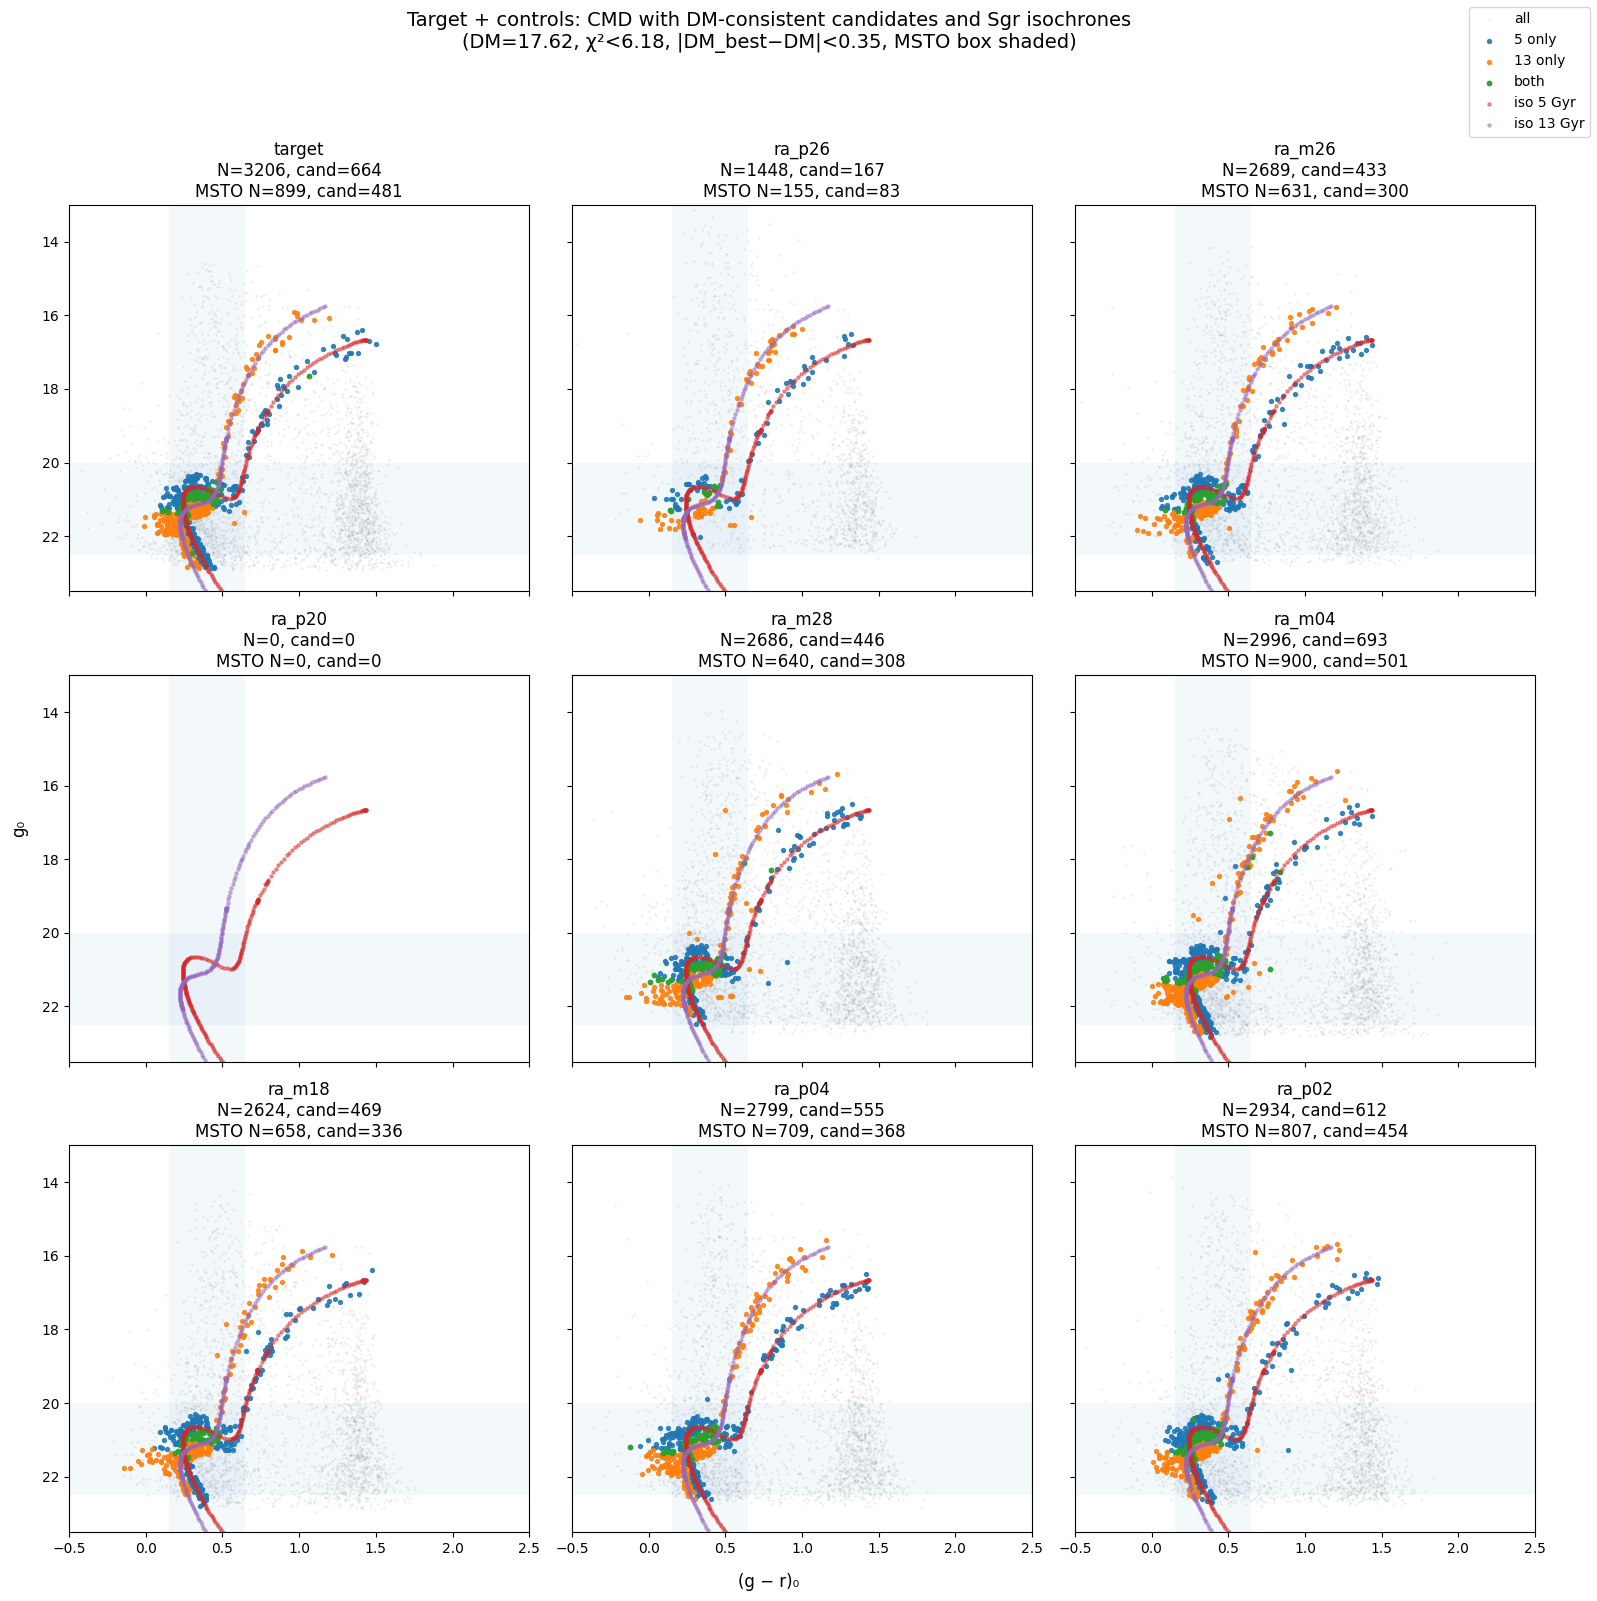

In [27]:
# cell 4: CMD comparison plots (target + a few controls) with candidates + isochrones

# --- pick fields to plot ---
random.seed(0)

field_map = {fid: df for fid, df in fields}
target_df = field_map["target"]

control_ids = [fid for fid, _ in fields if fid != "target"]
n_controls_to_plot = min(8, len(control_ids))
plot_ids = ["target"] + random.sample(control_ids, k=n_controls_to_plot)

# --- isochrones shifted to Sgr distance (for plotting only) ---
def iso_app_arrays(Mg_iso, Mr_iso, DM):
    g_app = Mg_iso + DM
    r_app = Mr_iso + DM
    c_app = g_app - r_app
    return c_app, g_app

c5_app, g5_app   = iso_app_arrays(Mg5,  Mr5,  DM_SGR)
c13_app, g13_app = iso_app_arrays(Mg13, Mr13, DM_SGR)

# --- subplot grid ---
n = len(plot_ids)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5.5*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, fid in zip(axes, plot_ids):
    dfp = field_map[fid]

    # background points (quality-cut already)
    ax.scatter(dfp["g_r"], dfp["g0"], s=1, alpha=0.08, color="gray", label="all")

    # emphasize MSTO region (box) for context
    ax.axvspan(msto["cmin"], msto["cmax"], alpha=0.05)
    ax.axhspan(msto["gmin"], msto["gmax"], alpha=0.05)

    # candidates (overall)
    ax.scatter(dfp.loc[dfp["cand_5"] & ~dfp["cand_13and13"] if False else dfp["cand_5"] & ~dfp["cand_13"], "g_r"],
               dfp.loc[dfp["cand_5"] & ~dfp["cand_13"], "g0"],
               s=8, alpha=0.85, label="5 only")

    ax.scatter(dfp.loc[dfp["cand_13"] & ~dfp["cand_5"], "g_r"],
               dfp.loc[dfp["cand_13"] & ~dfp["cand_5"], "g0"],
               s=8, alpha=0.85, label="13 only")

    ax.scatter(dfp.loc[dfp["cand_both"], "g_r"],
               dfp.loc[dfp["cand_both"], "g0"],
               s=10, alpha=0.95, label="both")

    # isochrones as points (avoid line zig-zags)
    ax.scatter(c5_app,  g5_app,  s=5, alpha=0.45, label="iso 5 Gyr")
    ax.scatter(c13_app, g13_app, s=5, alpha=0.45, label="iso 13 Gyr")

    # titles with counts
    N = len(dfp)
    Nc = int(dfp["cand_either"].sum())
    Nm = int(dfp["in_msto"].sum())
    Ncm = int((dfp["cand_either"] & dfp["in_msto"]).sum())
    ax.set_title(f"{fid}\nN={N}, cand={Nc}\nMSTO N={Nm}, cand={Ncm}")

    ax.invert_yaxis()
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(23.5, 13)

# turn off unused axes
for k in range(len(plot_ids), len(axes)):
    axes[k].axis("off")

# labels + legend
fig.text(0.5, 0.04, "(g − r)₀", ha="center", fontsize=12)
fig.text(0.04, 0.5, "g₀", va="center", rotation="vertical", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:6], labels[:6], loc="upper right", fontsize=10)

fig.suptitle(
    f"Target + controls: CMD with DM-consistent candidates and Sgr isochrones\n"
    f"(DM={DM_SGR:.2f}, χ²<{CHI2_THRESH}, |DM_best−DM|<{DM_TOL}, MSTO box shaded)",
    y=0.995, fontsize=14
)

plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.96])
plt.show()

,field,N_msto,N_cand_msto,f_cand_msto
1,ra_m02,855,478,0.559064
2,ra_m04,900,501,0.556667
3,ra_m06,976,525,0.537910
4,ra_m08,979,544,0.555669
5,ra_m10,924,463,0.501082
6,ra_m12,853,461,0.540445
7,ra_m14,813,411,0.505535
8,ra_m16,720,374,0.519444
9,ra_m18,658,336,0.510638
10,ra_m20,590,294,0.498305


=== Overdensity (MSTO only, DM-consistent candidates) ===
Target:    N=899, N_cand=481, f=0.53504
Controls:  mean f=0.50436, std f=0.04375  (n=30)
Excess:    Δf=0.03067
Significance: S = 0.70 σ
Empirical one-sided p-value (controls >= target): p = 0.258


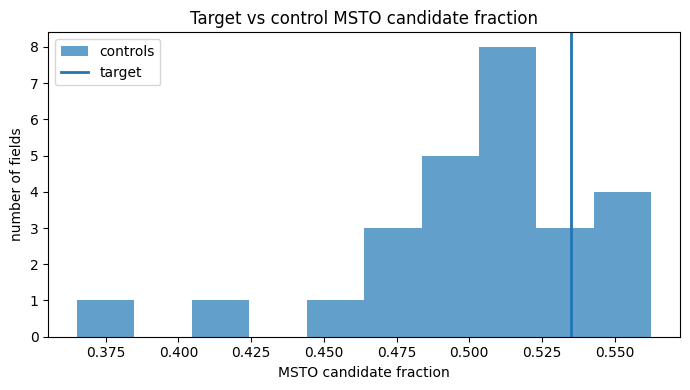

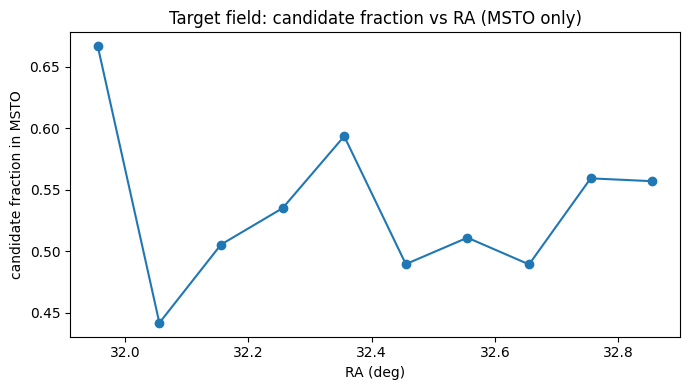

Linear trend: f(RA) ≈ -0.02563*RA + 1.365


In [24]:
# ---------- overdensity (MSTO only) ----------
rows = []
for fid, df in fields:
    sub = df[df["in_msto"]].copy()
    N = len(sub)
    Nc = int(sub["cand_either"].sum())
    f = Nc / N if N > 0 else np.nan
    rows.append({"field": fid, "N_msto": N, "N_cand_msto": Nc, "f_cand_msto": f})

summary = pd.DataFrame(rows).sort_values("field")
display(summary)

target = summary[summary["field"] == "target"].iloc[0]
controls = summary[summary["field"] != "target"].copy()

mu = controls["f_cand_msto"].mean()
sigma = controls["f_cand_msto"].std(ddof=1)
S = (target["f_cand_msto"] - mu) / sigma if sigma > 0 else np.nan

print("=== Overdensity (MSTO only, DM-consistent candidates) ===")
print(f"Target:    N={int(target['N_msto'])}, N_cand={int(target['N_cand_msto'])}, f={target['f_cand_msto']:.5f}")
print(f"Controls:  mean f={mu:.5f}, std f={sigma:.5f}  (n={len(controls)})")
print(f"Excess:    Δf={target['f_cand_msto']-mu:.5f}")
print(f"Significance: S = {S:.2f} σ")

# empirical p-value
ctrl_f = controls["f_cand_msto"].to_numpy()
p = (np.sum(ctrl_f >= target["f_cand_msto"]) + 1) / (len(ctrl_f) + 1)
print(f"Empirical one-sided p-value (controls >= target): p = {p:.3f}")

plt.figure(figsize=(7,4))
plt.hist(ctrl_f[np.isfinite(ctrl_f)], bins=10, alpha=0.7, label="controls")
plt.axvline(target["f_cand_msto"], linewidth=2, label="target")
plt.xlabel("MSTO candidate fraction")
plt.ylabel("number of fields")
plt.title("Target vs control MSTO candidate fraction")
plt.legend()
plt.tight_layout()
plt.show()


# ---------- spatial gradient test (target only) ----------
df_t = dict(fields)["target"].copy()
t = df_t[df_t["in_msto"]].copy()

# RA bins across the target field
nbin = 10
bins = np.linspace(t["ra"].min(), t["ra"].max(), nbin+1)
centers = 0.5*(bins[:-1] + bins[1:])

cand_density = []
all_density = []
for lo, hi in zip(bins[:-1], bins[1:]):
    s = t[(t["ra"] >= lo) & (t["ra"] < hi)]
    # surface density ~ counts / (bin area). Area per RA-bin is constant up to cos(dec) factor.
    cand_density.append(s["cand_either"].sum() / len(s) if len(s)>0 else np.nan)
    all_density.append(len(s))

plt.figure(figsize=(7,4))
plt.plot(centers, cand_density, marker="o")
plt.xlabel("RA (deg)")
plt.ylabel("candidate fraction in MSTO")
plt.title("Target field: candidate fraction vs RA (MSTO only)")
plt.tight_layout()
plt.show()

# quick linear trend fit (ignore empty bins)
x = centers[np.isfinite(cand_density)]
y = np.array(cand_density)[np.isfinite(cand_density)]
if len(x) >= 3:
    m, b = np.polyfit(x, y, 1)
    print(f"Linear trend: f(RA) ≈ {m:.4g}*RA + {b:.4g}")
else:
    print("Not enough non-empty bins for a trend fit.")